# *0. Ознакомиться с [блокнотом](https://colab.research.google.com/drive/1PwN8igT5w2xArBGmM6rvO9pVRQMh-FQn?usp=sharing)

# 1. Дерево решений для классификации

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.datasets import load_diabetes, make_regression

### Получение данных

Будем работать с набором данных для задачи классификации - данные по сердечно сосудистым заболеваниям, довольно стандартный набор для изучения машинного обучения, но его нет в `sklearn'e`. Поэтому скачиваем данные со стороны, с google диска.

Ссылка на google drive: https://drive.google.com/file/d/1Si4EJ_RexI3Q7yZU8eLjgp4ORe_BXr4G


--2023-10-10 11:29:32--  https://drive.google.com/uc?export=download&id=1Si4EJ_RexI3Q7yZU8eLjgp4ORe_BXr4G
Resolving drive.google.com (drive.google.com)... 74.125.201.101, 74.125.201.138, 74.125.201.139, ...
Connecting to drive.google.com (drive.google.com)|74.125.201.101|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://doc-00-c0-docs.googleusercontent.com/docs/securesc/ha0ro937gcuc7l7deffksulhg5h7mbp1/vuo7oo7cnp70g3fqvo67fr9tssm5fj7m/1696937325000/14904333240138417226/*/1Si4EJ_RexI3Q7yZU8eLjgp4ORe_BXr4G?e=download&uuid=1ce4782a-60ba-426f-becf-e6ed1ef563fe [following]
--2023-10-10 11:29:33--  https://doc-00-c0-docs.googleusercontent.com/docs/securesc/ha0ro937gcuc7l7deffksulhg5h7mbp1/vuo7oo7cnp70g3fqvo67fr9tssm5fj7m/1696937325000/14904333240138417226/*/1Si4EJ_RexI3Q7yZU8eLjgp4ORe_BXr4G?e=download&uuid=1ce4782a-60ba-426f-becf-e6ed1ef563fe
Resolving doc-00-c0-docs.googleusercontent.com (doc-00-c0-docs.googleusercontent.com)... 173.194.74.132, 2607:

В задаче предалагается предсказать наличие сердечно-сосудистых заболеваний по результатам классического врачебного осмотра. Датасет сформирован 3 групп признаков:

Объективные признаки:
- Возраст (в днях)
- Рост
- Вес
- Пол

Результаты измерения:

- Артериальное давление верхнее и нижнее
- Холестерин (три группы: норма, выше нормы, значительно выше нормы)
- Глюкоза (три группы: норма, выше нормы, значительно выше нормы)

Субъективные признаки (бинарные):

- Курение
- Употребление Алкоголя
- Физическая активность

In [2]:
df = pd.read_csv(r'C:\Users\pasha\OneDrive\Рабочий стол\6 решающие деревья\train_case2.csv', sep=';')
df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [3]:
full_features = ['age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo',
                 'cholesterol', 'gluc', 'smoke', 'alco', 'active']
target = 'cardio'

In [4]:
df['age'] = round(df['age'] / 365)

## 1. Вводная

### 1.1 Сколько вопросов будет задано на первом этапе

Посчитайте, сколько вопросов задаст дерево решений в самый первый раз, если использовать все признаки из списка full_features.

In [5]:
X = df[full_features]
y = df[target]

tree_full = DecisionTreeClassifier(random_state=1)
tree_full.fit(X, y)

questions = np.sum(tree_full.tree_.children_left != -1)
questions

np.int64(23204)

### 1.2 Упростите задачу

Вопросов получилось достаточно, не будет моделировать столько вопросов, а попробуем уменьшить их количество.

Возьмите только два признака: weight и gluc.
А так же возьмите только 10 первых объектов.

In [6]:
features = ['weight', 'gluc']
X = df[features]

tree_small = DecisionTreeClassifier(random_state=1)
tree_small.fit(X, y)

questions = np.sum(tree_small.tree_.children_left != -1)
questions

np.int64(458)

### 1.3 Посчитайте еще раз, сколько будет вопросов

In [7]:
questions = np.sum(tree_small.tree_.children_left != -1)
questions

np.int64(458)

С таким количеством вопросов уже можем работать и разбираться в устройству дерева решений.

## 2. Устройство дерева решений

### 2.1 Обучите дерево решений

Обучите дерево решений из sklearn'a с атрибутом `random_state=1`.

In [8]:
X = df[['weight', 'gluc']]
y = df[target]

tree = DecisionTreeClassifier(random_state=1)
tree.fit(X, y)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",1
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split among considered features for this split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: splitting may inspect more than ``max_features`` features ifneeded to find a valid split.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples 

### 2.2 Отрисуйте обученное дерево решений

Нарисуйте дерево решений, которое у вас получилось после обучения. Сделайте отрисовку такой, чтобы можно было понять, какие вопросы задаются

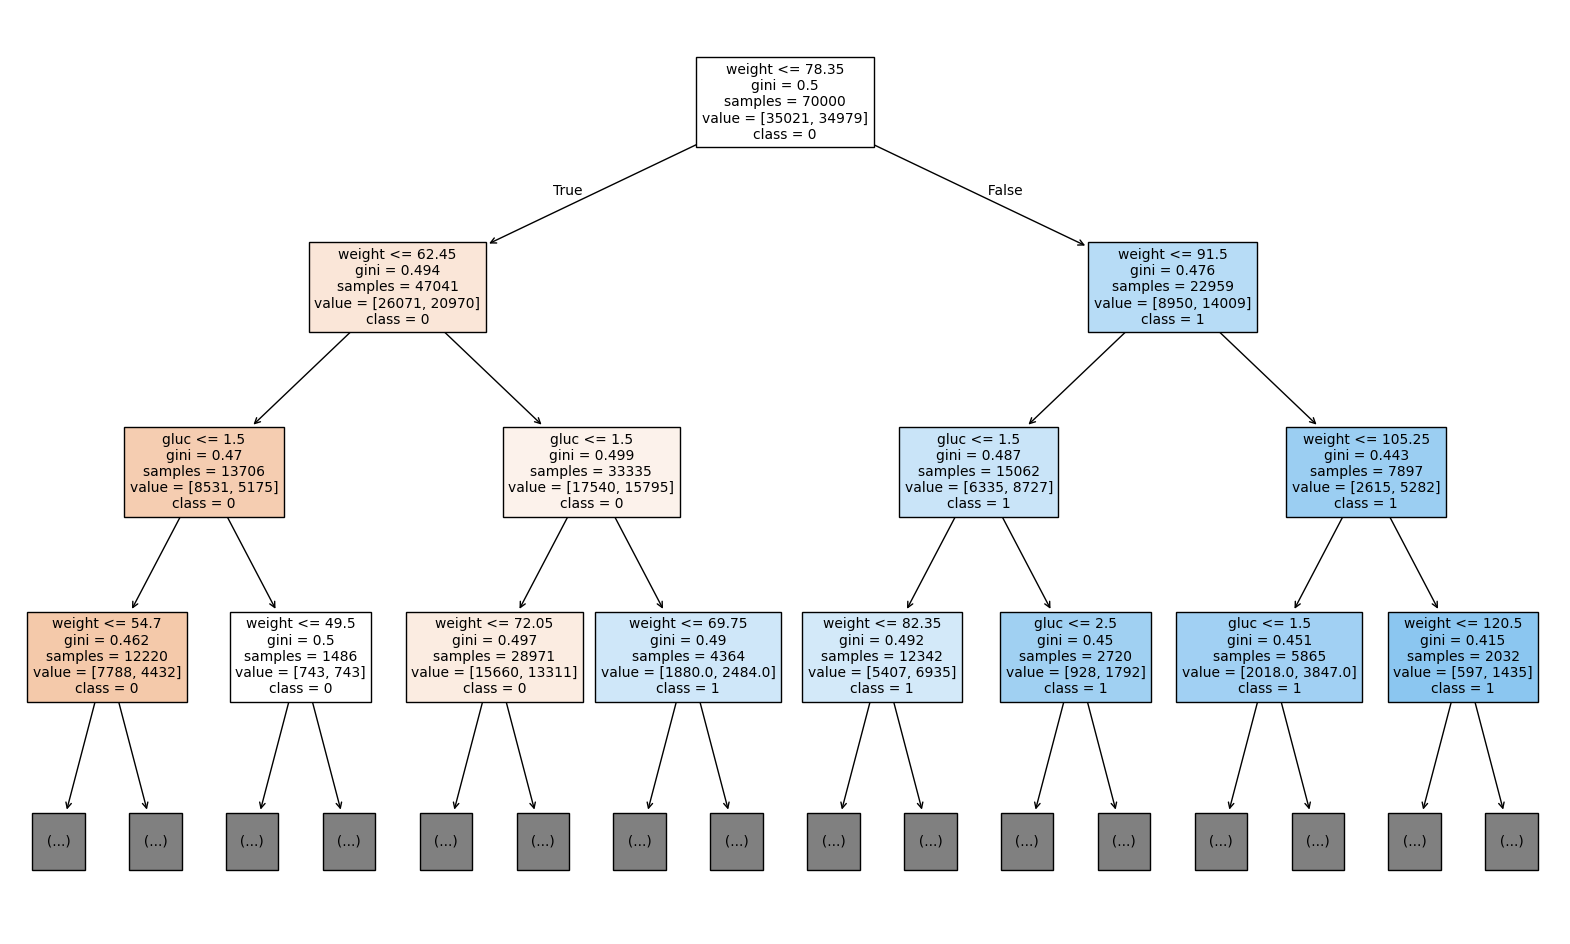

In [10]:
plt.figure(figsize=(20, 12))

plot_tree(
    tree,
    feature_names=['weight', 'gluc'],
    class_names=['0', '1'],
    filled=True,
    max_depth=3,
    fontsize=10
)

plt.show()

### 2.3 Посчитайте, сколько вершин получилось

In [11]:
nodes = tree.tree_.node_count
leaves = tree.tree_.n_leaves
questions = nodes - leaves
print('Количество вершин:', nodes)
print('Количество вопросов:', questions)

Количество вершин: 917
Количество вопросов: 458


### 2.4 Посчитайте, сколько листов получилось

In [12]:
print('Количество листьев:', tree.tree_.n_leaves)

Количество листьев: 459


### 2.5 Посмотрите, почему не получилось сделать разбиение ещё на два узла в крайнем левом узле.

В узле, где
```
gini=0.5
samples=2
value=[1, 1]
```

In [18]:
for i in range(tree.tree_.node_count):
    if tree.tree_.n_node_samples[i] == 2 and tree.tree_.impurity[i] == 0.5:
        print('Номер узла:', i)
        print('gini:', tree.tree_.impurity[i])
        print('samples:', tree.tree_.n_node_samples[i])
        print('value:', tree.tree_.value[i][0])
        print('В этом узле два объекта разных классов, поэтому критерий Джини равен 0.5')
        print('Если значения признаков у объектов одинаковые, разделить их следующим вопросом нельзя')
        break

Номер узла: 20
gini: 0.5
samples: 2
value: [0.5 0.5]
В этом узле два объекта разных классов, поэтому критерий Джини равен 0.5
Если значения признаков у объектов одинаковые, разделить их следующим вопросом нельзя


## 3. Вспомогательные функции

Для того, что бы дальше сравнивать между собой объекты нужно реализовать две вспомогательные функции.

### 3.1 Функция подсчета критерия Джини

Функция должна принимать список целевых значений, считать критерий информативности и выдавать одно значение - критерий Джини.

In [19]:
def gini(values):
    values = np.array(values)
    classes, counts = np.unique(values, return_counts=True)
    p = counts / len(values)
    return 1 - np.sum(p ** 2)

gini([0, 0, 1, 1])

np.float64(0.5)

### 3.2 Проверка функции gini

Посчитайте критерий информативности в исходной выборке и вы должны получить точно такое же значение, как и было на визуализации дерева решений в его корне.

In [20]:
gini_value = gini(y)
print('Критерий Джини:', gini_value)
print('Критерий Джини в корне дерева:', tree.tree_.impurity[0])

Критерий Джини: 0.49999982
Критерий Джини в корне дерева: 0.49999982


### 3.3 Функция подсчета прироста информации

Функция должна принимать целевые значения левой подвыборки, правой подвыборки и исходной вершины, а выдавать должна одно значение - прирост информации, подсчитанный на критерии информативности Джини.

In [21]:
def information_gain(y_left, y_right, y_parent):
    n = len(y_parent)
    n_left = len(y_left)
    n_right = len(y_right)
    return gini(y_parent) - (n_left / n) * gini(y_left) - (n_right / n) * gini(y_right)

left = [0, 0]
right = [1, 1]
parent = left + right
information_gain(left, right, parent)

np.float64(0.5)

Теперь вспомогательные функции готовы можем моделировать работу обученного дерева решений.

## 4. Процесс построения дерева решений

### 4.1 Получение первого вопроса


4.1.1 Пройдитесь по всем возможным вопросам для исходного набора данных


Можете сохранять полученные значения прироста информации в датафрейм в удобную для вас структуру данных.

In [22]:
results = []

for feature in features:
    values = sorted(df[feature].unique())
    for i in range(len(values) - 1):
        threshold = (values[i] + values[i + 1]) / 2
        left = df[df[feature] <= threshold][target]
        right = df[df[feature] > threshold][target]
        if len(left) > 0 and len(right) > 0:
            gain = information_gain(left.values, right.values, y.values)
            results.append([feature, threshold, gain])

results = pd.DataFrame(results, columns=['feature', 'threshold', 'gain'])
results.sort_values('gain', ascending=False).head(10)

,feature,threshold,gain
145,weight,78.35,0.011913
144,weight,78.10,0.011913
138,weight,75.80,0.011911
135,weight,75.10,0.011911
146,weight,78.75,0.011909
137,weight,75.55,0.011907
136,weight,75.35,0.011906
126,weight,73.10,0.011884
129,weight,73.90,0.011880
128,weight,73.65,0.011875


4.1.2 Найдите самый лучший вопрос, опираясь на прирост информации

In [23]:
best = results.sort_values('gain', ascending=False).iloc[0]
print('Лучший признак:', best['feature'])
print('Лучший порог:', best['threshold'])
print('Прирост информации:', best['gain'])

Лучший признак: weight
Лучший порог: 78.35
Прирост информации: 0.011913291243523333


4.1.3. Сделайте разбиение по этому вопросу исходных данных на две подвыборки df_left и df_right


In [24]:
best_feature = best['feature']
best_threshold = best['threshold']

df_left = df[df[best_feature] <= best_threshold].copy()
df_right = df[df[best_feature] > best_threshold].copy()

print('df_left:', df_left.shape)
print('df_right:', df_right.shape)

df_left: (47041, 13)
df_right: (22959, 13)


4.1.4. Проверьте себя через визуализацию дерева решений

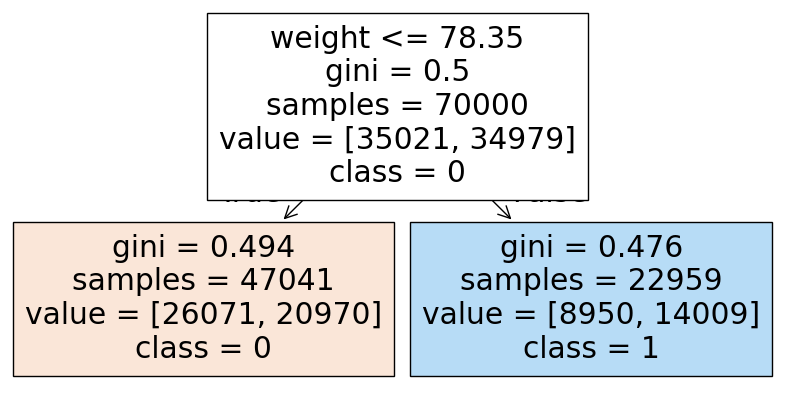

In [25]:
tree_first = DecisionTreeClassifier(max_depth=1, random_state=1)
tree_first.fit(df[features], y)

plt.figure(figsize=(10, 5))
plot_tree(tree_first, feature_names=features, class_names=['0', '1'], filled=True)
plt.show()

### 4.2 Получение второго вопроса


4.2.1. Глядя на df_left и df_right, посмотрите, где можно сделать ещё разбиение

In [27]:
print('Смотрим на размеры подвыборок:')
print('df_left:', df_left.shape)
print('df_right:', df_right.shape)
print('Для следующего разбиения выбираем подвыборку, в которой еще есть объекты разных классов')

Смотрим на размеры подвыборок:
df_left: (47041, 13)
df_right: (22959, 13)
Для следующего разбиения выбираем подвыборку, в которой еще есть объекты разных классов


4.2.2. Пройдитесь по всем признакам в выбранной подвыборке

In [28]:
sub = df_left if df_left[target].nunique() > 1 else df_right

results_second = []
for feature in features:
    values = sorted(sub[feature].unique())
    for i in range(len(values) - 1):
        threshold = (values[i] + values[i + 1]) / 2
        left = sub[sub[feature] <= threshold][target]
        right = sub[sub[feature] > threshold][target]
        if len(left) > 0 and len(right) > 0:
            gain = information_gain(left.values, right.values, sub[target].values)
            results_second.append([feature, threshold, gain])

results_second = pd.DataFrame(results_second, columns=['feature', 'threshold', 'gain'])
results_second.sort_values('gain', ascending=False).head(10)

,feature,threshold,gain
78,weight,62.45,0.003826
79,weight,62.60,0.003825
80,weight,62.85,0.003820
77,weight,62.35,0.003819
75,weight,62.10,0.003817
76,weight,62.25,0.003812
87,weight,64.40,0.003763
86,weight,64.20,0.003760
85,weight,64.05,0.003756
88,weight,64.60,0.003749


4.2.3 Найдите самый лучший вопрос, опираясь на прирост информации

In [29]:
best_second = results_second.sort_values('gain', ascending=False).iloc[0]
print('Лучший признак:', best_second['feature'])
print('Лучший порог:', best_second['threshold'])
print('Прирост информации:', best_second['gain'])

Лучший признак: weight
Лучший порог: 62.45
Прирост информации: 0.0038258651313123893


4.2.4. Сделайте разбиение по этому вопросу исходных данных на две подвыборки df_left и df_right


In [30]:
second_feature = best_second['feature']
second_threshold = best_second['threshold']

second_left = sub[sub[second_feature] <= second_threshold].copy()
second_right = sub[sub[second_feature] > second_threshold].copy()

print('second_left:', second_left.shape)
print('second_right:', second_right.shape)

second_left: (13706, 13)
second_right: (33335, 13)


4.2.5. Проверьте себя через визуализацию дерева решений

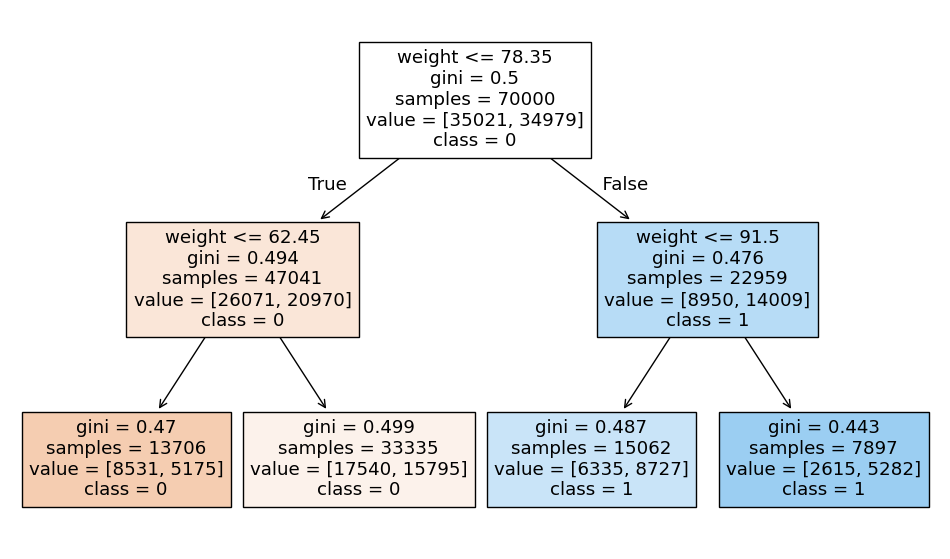

In [31]:
tree_two = DecisionTreeClassifier(max_depth=2, random_state=1)
tree_two.fit(df[features], y)

plt.figure(figsize=(12, 7))
plot_tree(tree_two, feature_names=features, class_names=['0', '1'], filled=True)
plt.show()

4.2.6. Если что-то не сошлось, посмотрите, в чем может быть проблема

In [33]:
print('Ручное разбиение сравниваем с первыми двумя уровнями дерева')
print('Первый вопрос:', tree_two.tree_.feature[0], tree_two.tree_.threshold[0])
print('Если значения немного отличаются, это связано с тем, что sklearn выбирает лучший порог автоматически')

Ручное разбиение сравниваем с первыми двумя уровнями дерева
Первый вопрос: 0 78.3499984741211
Если значения немного отличаются, это связано с тем, что sklearn выбирает лучший порог автоматически


# 2. Дерево решений для регрессии

In [34]:

from sklearn.tree import DecisionTreeRegressor, plot_tree

### 1. Получение данных load_breat_cancer

Будем работать с набором данных для задачи регрессии `load_diabetes`, который можно получить из стандартных датасетов в `sklearn'e`.

После `load_diabetes()` возвращается словарь с данными (`data`), целевой переменной (`target`), названиями характеристик в данных (`feature_names`) и описанием данных (`DESCR`).

In [35]:
from sklearn.datasets import load_diabetes

data = load_diabetes()
data

{'data': array([[ 0.03807591,  0.05068012,  0.06169621, ..., -0.00259226,
          0.01990749, -0.01764613],
        [-0.00188202, -0.04464164, -0.05147406, ..., -0.03949338,
         -0.06833155, -0.09220405],
        [ 0.08529891,  0.05068012,  0.04445121, ..., -0.00259226,
          0.00286131, -0.02593034],
        ...,
        [ 0.04170844,  0.05068012, -0.01590626, ..., -0.01107952,
         -0.04688253,  0.01549073],
        [-0.04547248, -0.04464164,  0.03906215, ...,  0.02655962,
          0.04452873, -0.02593034],
        [-0.04547248, -0.04464164, -0.0730303 , ..., -0.03949338,
         -0.00422151,  0.00306441]]),
 'target': array([151.,  75., 141., 206., 135.,  97., 138.,  63., 110., 310., 101.,
         69., 179., 185., 118., 171., 166., 144.,  97., 168.,  68.,  49.,
         68., 245., 184., 202., 137.,  85., 131., 283., 129.,  59., 341.,
         87.,  65., 102., 265., 276., 252.,  90., 100.,  55.,  61.,  92.,
        259.,  53., 190., 142.,  75., 142., 155., 225.,  59

In [36]:
X = data.data
features = data.feature_names
y = data.target

Из признаков (характеристик данных) и целевой переменной сформируем датафрейм, в качестве названий колонок возьмем названия признаков.

In [37]:
df = pd.DataFrame(X, columns=features)
df['target'] = y

df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


Разобьем выборку на две: обучающую и тестовую.

In [38]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df[features],
    df['target'],
    test_size=0.2,
    shuffle=True,
    random_state=3
)

X_train.shape, y_train.shape, X_test.shape, y_test.shape

((353, 10), (353,), (89, 10), (89,))

### 1.1. Обучение дерева решений

1. Инициализируйте дерево решений для задачи регрессии
2. Обучите его на обучающей выборке

In [39]:
tree = DecisionTreeRegressor(random_state=1)
tree.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",1
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split among considered features for this split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: splitting may inspect more than ``max_features`` features ifneeded to find a valid split.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with 

### 1.2. Получение метрик качества
Узнаем, насколько дерево решений обучилось хорошо, для этого
1. Сделайте предсказания моделью для обучающей выборки
2. Сделайте предсказания моделью для тестовой выборки
3. Посчитайте метрику качества средне-квадратичная ошибка
4. Посчитайте метрику качества коэффициент детерминации

In [40]:
pred_train = tree.predict(X_train)
pred_test = tree.predict(X_test)

mse_train = mean_squared_error(y_train, pred_train)
mse_test = mean_squared_error(y_test, pred_test)
r2_train = r2_score(y_train, pred_train)
r2_test = r2_score(y_test, pred_test)

print('MSE на обучении:', mse_train)
print('MSE на тесте:', mse_test)
print('R2 на обучении:', r2_train)
print('R2 на тесте:', r2_test)

MSE на обучении: 0.0
MSE на тесте: 5897.134831460674
R2 на обучении: 1.0
R2 на тесте: -0.08909766517566808


Сделайте вывод, насколько хорошо обучилась модель

In [ ]:
На обучающей выборке дерево показывает очень хорошее качество, но на тестовой выборке качество ниже. Это связано с тем, что дерево без ограничений может переобучиться

### 1.3. Изменение метрики

Попробуйте поизменять известные параметры для того, чтобы метрика стала лучше.

In [41]:
tree = DecisionTreeRegressor(random_state=1, max_depth=4, min_samples_leaf=5)
tree.fit(X_train, y_train)

pred_train = tree.predict(X_train)
pred_test = tree.predict(X_test)

print('MSE на обучении:', mean_squared_error(y_train, pred_train))
print('MSE на тесте:', mean_squared_error(y_test, pred_test))
print('R2 на обучении:', r2_score(y_train, pred_train))
print('R2 на тесте:', r2_score(y_test, pred_test))

MSE на обучении: 2509.8595000833648
MSE на тесте: 3718.3038257796493
R2 на обучении: 0.5851209287110646
R2 на тесте: 0.3132943148143491


In [ ]:
После ограничения глубины и минимального числа объектов в листе дерево становится проще. Это может уменьшить переобучение и улучшить качество на тестовой выборке

### 2. Получение данных make_regression

Для второго примера возьмем самодельный набор данных для задачи регрессии `make_regression`, который можно получить из стандартных датасетов в `sklearn'e`.

Сгенерируем себе 100к объектов, которые описываются 20 признаками, из них 12 будут дейтсвительно полезными.

In [42]:
from sklearn.datasets import make_regression

X, y = make_regression(n_samples=100_000, n_features=20, n_informative=12, random_state=10)

In [43]:
X.shape, y.shape

((100000, 20), (100000,))

Разобьем выборку на две: обучающую и тестовую.

In [44]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=True,
    random_state=3
)

X_train.shape, y_train.shape, X_test.shape, y_test.shape

((80000, 20), (80000,), (20000, 20), (20000,))

### 2.1. Обучение дерева решений

1. Инициализируйте дерево решений для задачи регрессии
2. Обучите его на обучающей выборке

In [45]:
tree = DecisionTreeRegressor(random_state=1)
tree.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",1
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split among considered features for this split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: splitting may inspect more than ``max_features`` features ifneeded to find a valid split.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with 

### 2.2. Получение метрик качества
Узнаем, насколько дерево решений обучилось хорошо, для этого
1. Сделайте предсказания моделью для обучающей выборки
2. Сделайте предсказания моделью для тестовой выборки
3. Посчитайте метрику качества средне-квадратичная ошибка
4. Посчитайте метрику качества коэффициент детерминации

In [46]:
pred_train = tree.predict(X_train)
pred_test = tree.predict(X_test)

print('MSE на обучении:', mean_squared_error(y_train, pred_train))
print('MSE на тесте:', mean_squared_error(y_test, pred_test))
print('R2 на обучении:', r2_score(y_train, pred_train))
print('R2 на тесте:', r2_score(y_test, pred_test))

MSE на обучении: 0.0
MSE на тесте: 16653.348146704826
R2 на обучении: 1.0
R2 на тесте: 0.6915358863274659


Сделайте вывод, насколько хорошо обучилась модель

In [ ]:
На большой выборке дерево без ограничений также может переобучаться: ошибка на обучении очень маленькая, а на тесте выше

### 2.3. Перебор гиперпараметров

Осуществите перебор параметров для получения лучших результатов (GridSearchCV, см. подход из п.0).

In [47]:
params = {
    'max_depth': [3, 5, 7, 10],
    'min_samples_leaf': [1, 5, 10]
}

model = DecisionTreeRegressor(random_state=1)
grid = GridSearchCV(model, params, cv=3, scoring='neg_mean_squared_error', n_jobs=-1)
grid.fit(X_train, y_train)

print('Лучшие параметры:', grid.best_params_)
print('Лучший MSE:', -grid.best_score_)

Лучшие параметры: {'max_depth': 10, 'min_samples_leaf': 10}
Лучший MSE: 17703.73645223468


In [48]:
best_tree = grid.best_estimator_
pred_train = best_tree.predict(X_train)
pred_test = best_tree.predict(X_test)

print('MSE на обучении:', mean_squared_error(y_train, pred_train))
print('MSE на тесте:', mean_squared_error(y_test, pred_test))
print('R2 на обучении:', r2_score(y_train, pred_train))
print('R2 на тесте:', r2_score(y_test, pred_test))

MSE на обучении: 12725.84865257862
MSE на тесте: 17128.3901851413
R2 на обучении: 0.7645415788436455
R2 на тесте: 0.6827368496381083
